# Static tree of shapes and residual trees tutorial

This version uses `dat/hydrant_2_3bit.png` and contains no widgets, browser callbacks, or interactive plots. `mmcfilters` constructs and filters the hierarchies, `mtviz.PrintTree` prints their complete topology, and Matplotlib records the input and filtered images as static notebook outputs.

## Goal

The notebook has four steps:

1. load and display `dat/hydrant_2_3bit.png`;
2. construct a tree of shapes and two residual trees;
3. print all three trees with `mtviz.PrintTree`; and
4. apply fixed thresholds for six attributes and display every filtered image.

## Setup

Run from the repository root or from `notebooks/`, using the project environment described in `README.md` and `notebooks/requirements.txt`.

,hydrant_2_3bit.png
path,../dat/hydrant_2_3bit.png
shape,352 x 363
pixels,127776
gray levels,5
range,109 .. 255


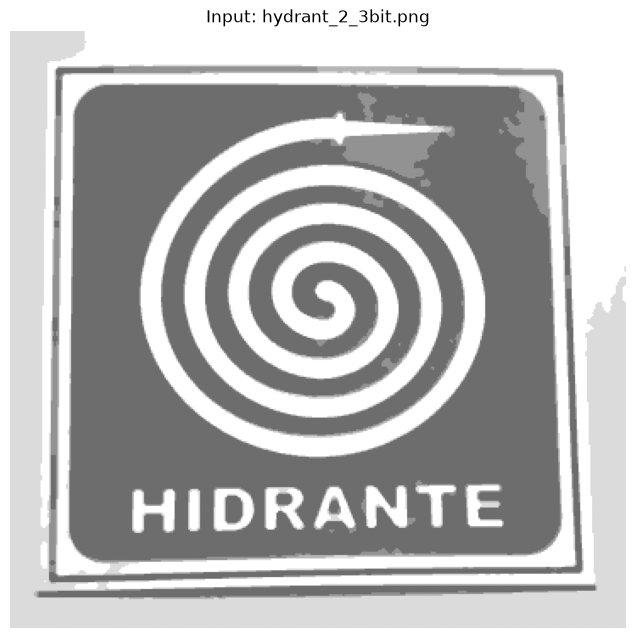

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import mmcfilters
import mtviz as viz
import numpy as np
import pandas as pd
from IPython.display import display

IMAGE_PATH = Path("dat/hydrant_2_3bit.png")
if not IMAGE_PATH.exists():
    IMAGE_PATH = Path("../dat/hydrant_2_3bit.png")

image = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_GRAYSCALE)
assert image is not None, f"Could not read {IMAGE_PATH}"
image = np.ascontiguousarray(image, dtype=np.uint8)
rows, columns = image.shape

display(
    pd.Series(
        {
            "path": IMAGE_PATH.as_posix(),
            "shape": f"{rows} x {columns}",
            "pixels": image.size,
            "gray levels": np.unique(image).size,
            "range": f"{image.min()} .. {image.max()}",
        },
        name="hydrant_2_3bit.png",
    ).to_frame()
)

INPUT_FIGURE_WIDTH = 8
figure, axis = plt.subplots(
    figsize=(INPUT_FIGURE_WIDTH, INPUT_FIGURE_WIDTH * rows / columns)
)
axis.imshow(image, cmap="gray", vmin=0, vmax=255)
axis.set_title("Input: hydrant_2_3bit.png")
axis.axis("off")
plt.show()

## 1. Build the hierarchies

The residual trees use shared 8-adjacency. The tree of shapes uses the library's default complementary Min4/Max8 convention.

In [3]:
RESIDUAL_RADIUS = 1.5
INFINITY_PIXEL = 0

factory = mmcfilters.MorphologicalTreeFactory
trees = {
    "Tree of Shapes": factory.create_tree_of_shapes(
        image, infinity_pixel=INFINITY_PIXEL
    ),
    "Saturated Residual": factory.create_saturated_residual_tree(
        image, infinity_pixel=INFINITY_PIXEL, radius=RESIDUAL_RADIUS
    ),
    "Unrestricted Residual": factory.create_unrestricted_residual_tree(
        image, radius=RESIDUAL_RADIUS
    ),
}

areas = {
    name: mmcfilters.Attribute.compute_single_topology_attribute(
        tree, mmcfilters.Attribute.AREA, dtype=np.float64
    )
    for name, tree in trees.items()
}

display(
    pd.DataFrame(
        [
            {
                "hierarchy": name,
                "nodes": tree.num_nodes,
                "leaves": len(tree.leaves),
                "root altitude": int(tree.node_altitude(tree.root)),
            }
            for name, tree in trees.items()
        ]
    ).set_index("hierarchy")
)

,nodes,leaves,root altitude
hierarchy,,,
Tree of Shapes,81,36,219
Saturated Residual,81,36,219
Unrestricted Residual,80,36,109


## 2. Print the complete trees with `mtviz.PrintTree`

Each textual node uses the compact label `id|h=altitude|r=residue|A=support area`. The output is intentionally complete and may require horizontal scrolling.

In [8]:
for tree_name, tree in trees.items():
    area = areas[tree_name]
    print(f"\n{tree_name} ({tree.num_nodes} nodes)")
    print_tree = viz.PrintTree(
        tree.children,
        lambda node, tree=tree, area=area: (
            f"{node}"
            #f"{node}|h={int(tree.node_altitude(node))}"
            #f"|r={int(tree.node_residue(node))}|A={int(area[node])}"
        ),
    )
    print_tree(tree.root)


Tree of Shapes (81 nodes)
                                                  0
┌─┬─┬─┬─┬──────────────────────────────┬──────────┴─────────────────────────────────────────────────┐
1 2 3 4 5                              7                                                            8 
|                   ┌─────────────┬────┴───────────────────┐                                        | 
6                   9             11                       22                                       10
          ┌──┬──┬──┬┴─┬──┬──┬──┐  |  ┌─────────────────────┴──────────────────────┐                 | 
          12 13 14 16 17 18 19 20 21 23                                           24                15
                                                                                  |                   
                                                                                  25                  
                                                                   ┌──────────────┴──────────────┐

## 3. Apply fixed attribute filters

The thresholds below match the initial values of the interactive tutorial. For each attribute, `mmcfilters.Attribute` computes the node values, `mmcfilters.AttributeFilters` performs pruning-min, and Matplotlib records one static row containing the three reconstructions.

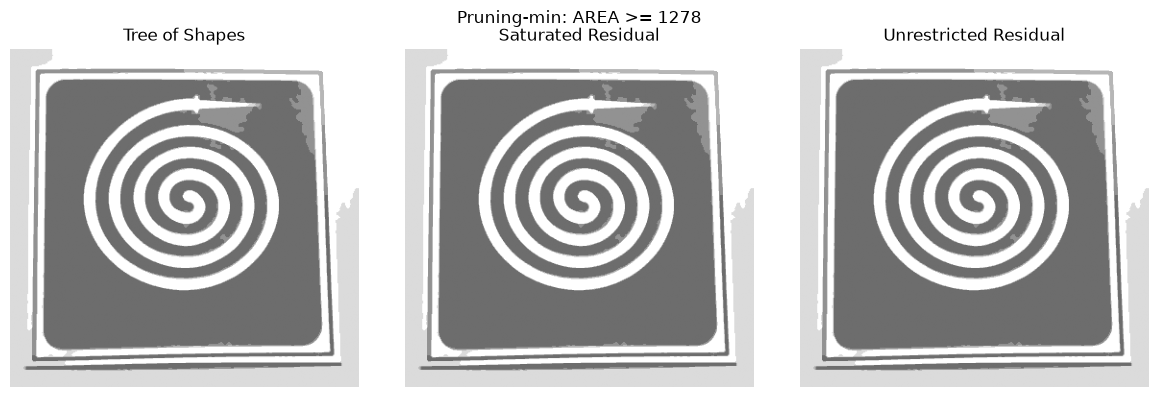

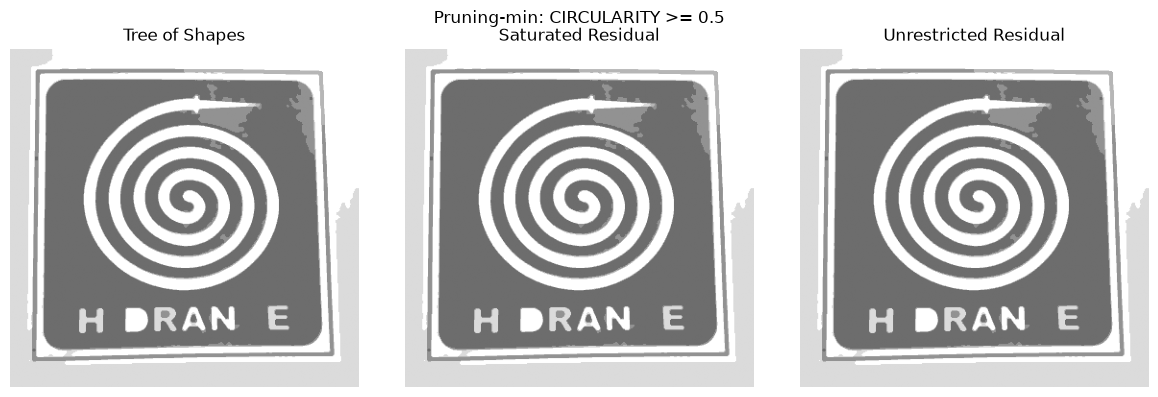

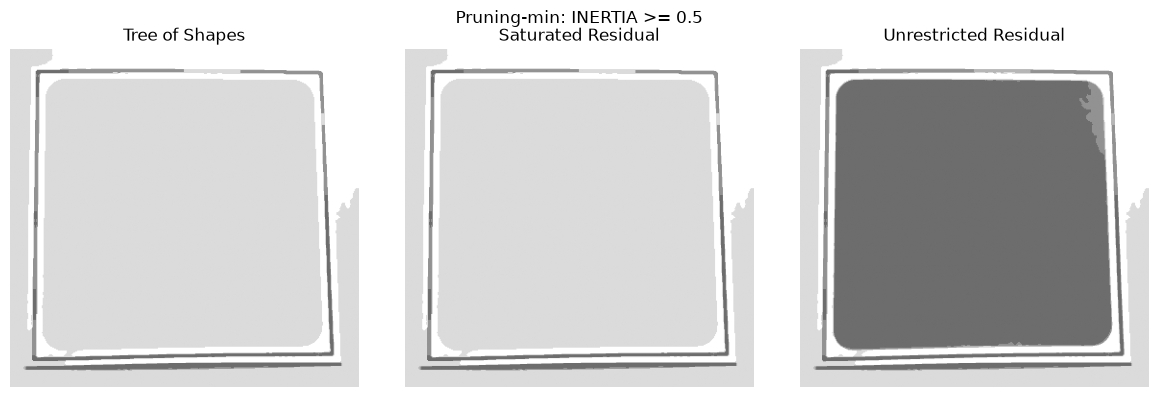

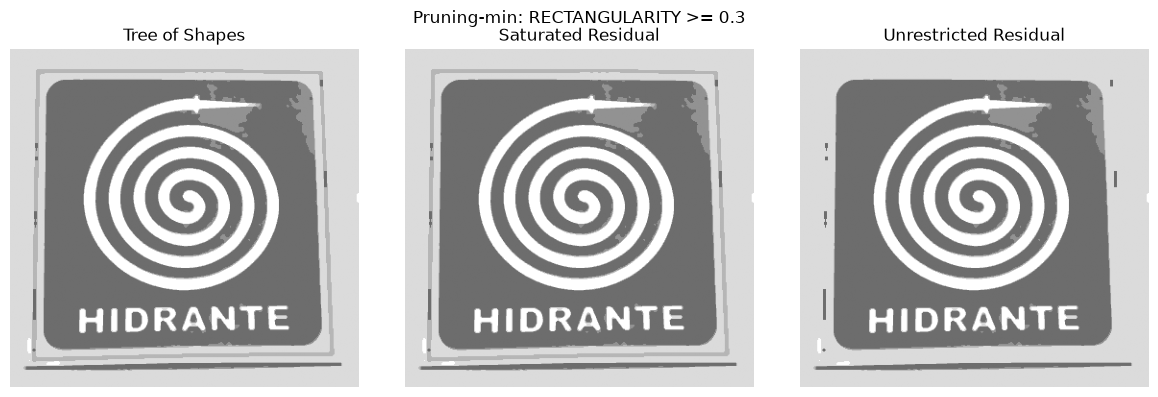

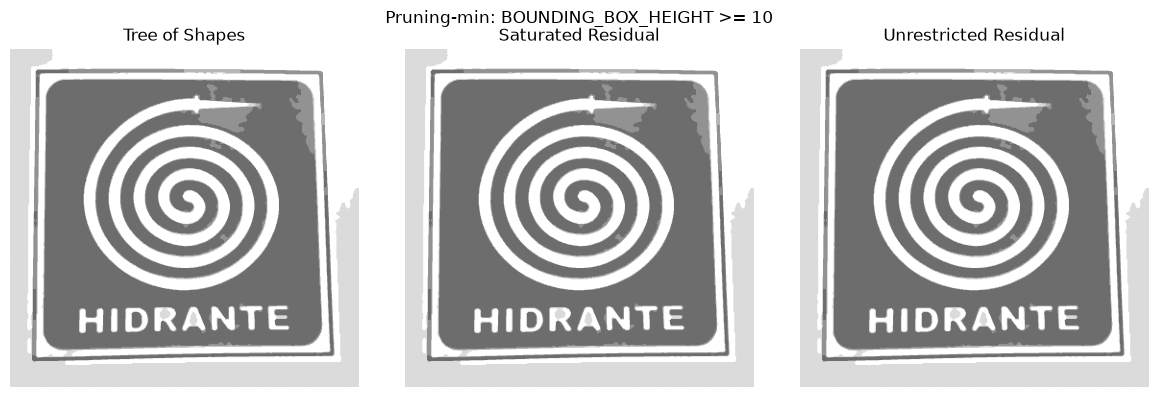

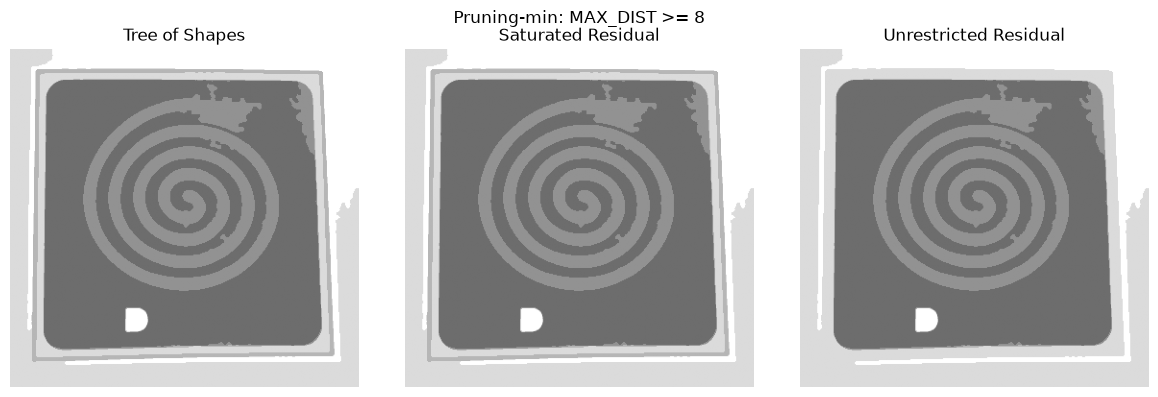

threshold  nodes meeting threshold  \
attribute           hierarchy                                                   
AREA                Tree of Shapes            1278.0                       17   
                    Saturated Residual        1278.0                       17   
                    Unrestricted Residual     1278.0                       16   
CIRCULARITY         Tree of Shapes               0.5                       44   
                    Saturated Residual           0.5                       44   
                    Unrestricted Residual        0.5                       43   
INERTIA             Tree of Shapes               0.5                       11   
                    Saturated Residual           0.5                       11   
                    Unrestricted Residual        0.5                       15   
RECTANGULARITY      Tree of Shapes               0.3                       75   
                    Saturated Residual           0.3                       75   
                    Unrestricted Residual        0.3                       73   
BOUNDING_BOX_HEIGHT Tree of Shapes              10.0                       58   
                    Saturated Residual          10.0                       58   
                    Unrestricted Residual       10.0                       57   
MAX_DIST            Tree of Shapes               8.0                       12   
                    Saturated Residual           8.0                       12   
                    Unrestricted Residual        8.0                       10   

                                           changed pixels  \
attribute           hierarchy                               
AREA                Tree of Shapes                   3890   
                    Saturated Residual               3890   
                    Unrestricted Residual            3890   
CIRCULARITY         Tree of Shapes                   5883   
                    Saturated Residual               5883   
                    Unrestricted Residual            5883   
INERTIA             Tree of Shapes                  78697   
                    Saturated Residual              78697   
                    Unrestricted Residual           22594   
RECTANGULARITY      Tree of Shapes                  26307   
                    Saturated Residual              26307   
                    Unrestricted Residual           27168   
BOUNDING_BOX_HEIGHT Tree of Shapes                   2260   
                    Saturated Residual               2260   
                    Unrestricted Residual            2260   
MAX_DIST            Tree of Shapes                  32988   
                    Saturated Residual              32988   
                    Unrestricted Residual           33849   

                                           remaining gray levels  
attribute           hierarchy                                     
AREA                Tree of Shapes                             5  
                    Saturated Residual                         5  
                    Unrestricted Residual                      5  
CIRCULARITY         Tree of Shapes                             5  
                    Saturated Residual                         5  
                    Unrestricted Residual                      5  
INERTIA             Tree of Shapes                             5  
                    Saturated Residual                         5  
                    Unrestricted Residual                      5  
RECTANGULARITY      Tree of Shapes                             5  
                    Saturated Residual                         5  
                    Unrestricted Residual                      5  
BOUNDING_BOX_HEIGHT Tree of Shapes                             5  
                    Saturated Residual                         5  
                    Unrestricted Residual                      5  
MAX_DIST            Tree of Shapes                            

In [18]:
FILTER_SPECS = {
    "AREA": (mmcfilters.Attribute.AREA, float(np.ceil(0.01 * image.size))),
    "CIRCULARITY": (mmcfilters.Attribute.CIRCULARITY, 0.50),
    "INERTIA": (mmcfilters.Attribute.INERTIA, 0.50),
    "RECTANGULARITY": (mmcfilters.Attribute.RECTANGULARITY, 0.30),
    "BOUNDING_BOX_HEIGHT": (mmcfilters.Attribute.BOUNDING_BOX_HEIGHT, 10.0),
    "MAX_DIST": (mmcfilters.Attribute.MAX_DIST, 8.0),
}
FILTER_FIGURE_SIZE = (12, 4)

filtered_results = {}
filter_summary_rows = []

for attribute_name, (attribute, threshold) in FILTER_SPECS.items():
    figure, axes = plt.subplots(1, len(trees), figsize=FILTER_FIGURE_SIZE)

    for axis, (tree_name, tree) in zip(axes, trees.items()):
        values = mmcfilters.Attribute.compute_single_topology_attribute(
            tree, attribute, dtype=np.float64
        )
        
        keep = (values > threshold).tolist()
        keep[tree.root] = True
        preservation_mask = mmcfilters.NodePreservationMask(keep)
        filtered_image = mmcfilters.DirectAttributeFilter(tree).apply(preservation_mask)
            
        filtered_results[(attribute_name, tree_name)] = filtered_image

        axis.imshow(filtered_image, cmap="gray", vmin=0, vmax=255)
        axis.set_title(tree_name)
        axis.axis("off")

        filter_summary_rows.append(
            {
                "attribute": attribute_name,
                "threshold": threshold,
                "hierarchy": tree_name,
                "nodes meeting threshold": int(np.count_nonzero(values >= threshold)),
                "changed pixels": int(np.count_nonzero(filtered_image != image)),
                "remaining gray levels": int(np.unique(filtered_image).size),
            }
        )

    figure.suptitle(f"Pruning-min: {attribute_name} >= {threshold:g}")
    figure.tight_layout()
    plt.show()

display(
    pd.DataFrame(filter_summary_rows).set_index(
        ["attribute", "hierarchy"]
    )
)